**Min-Max Scaling**  
Min-Max Scaling transforms features by subtracting the minimum value and dividing by the difference between the maximum and minimum values. This method maps feature values to a specified range, commonly 0 to 1, preserving the original distribution shape but is still affected by outliers due to reliance on extreme values.

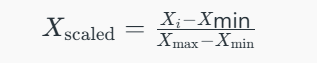

In [6]:
import pandas as pd

data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [10]:
X = data.drop(columns=["Outcome"])   # features
y = data["Outcome"]   

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)



In [23]:
import numpy as np
np.round(X_train.describe(), 1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0,537.0,537.0
mean,3.9,122.5,73.0,29.2,145.1,32.7,0.5,33.7
std,3.4,30.5,11.9,9.1,91.8,7.0,0.3,12.0
min,0.0,56.0,30.0,7.0,14.0,18.2,0.1,21.0
25%,1.0,100.0,66.0,25.0,102.5,27.8,0.2,24.0
50%,3.0,119.0,72.0,28.0,108.0,32.4,0.4,29.0
75%,6.0,142.0,80.0,33.0,169.5,36.8,0.6,41.0
max,17.0,198.0,122.0,99.0,846.0,67.1,2.4,81.0


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
glucose_before_scaling = X_train['BloodPressure'].copy()
# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
np.round(X_train_scaled.describe(), 1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0,537.0,537.0
mean,0.2,0.5,0.5,0.2,0.2,0.3,0.2,0.2
std,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.1,0.3,0.4,0.2,0.1,0.2,0.1,0.1
50%,0.2,0.4,0.5,0.2,0.1,0.3,0.1,0.1
75%,0.4,0.6,0.5,0.3,0.2,0.4,0.2,0.3
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


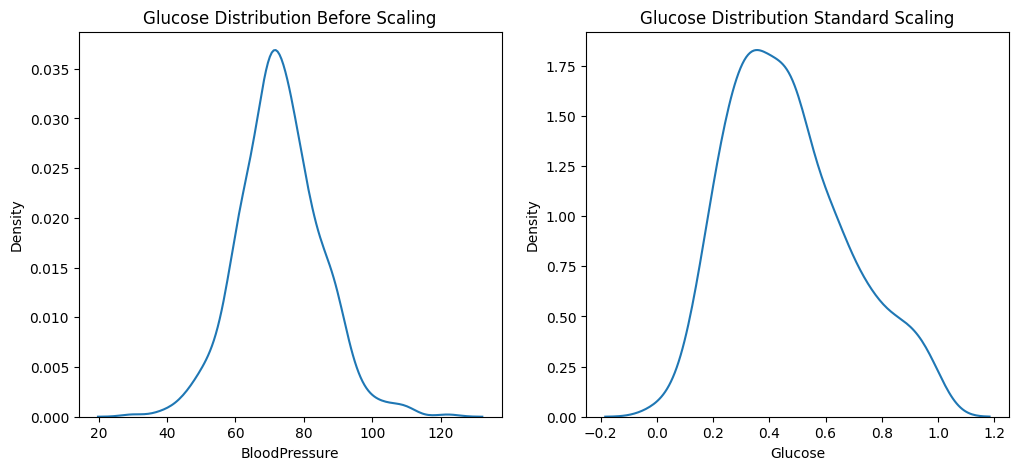

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Glucose Distribution Before Scaling')
sns.kdeplot(glucose_before_scaling, ax=ax1)

# after scaling
ax2.set_title('Glucose Distribution Standard Scaling')
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
sns.kdeplot(X_train_scaled['Glucose'], ax=ax2)
plt.show()

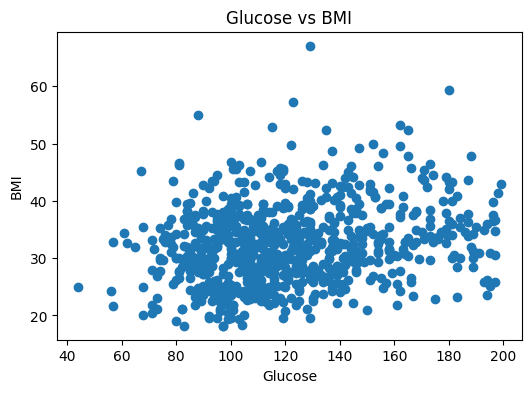

In [25]:
#Before Normalization Scaling
plt.figure(figsize=(6, 4))
plt.scatter(data["Glucose"], data["BMI"])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

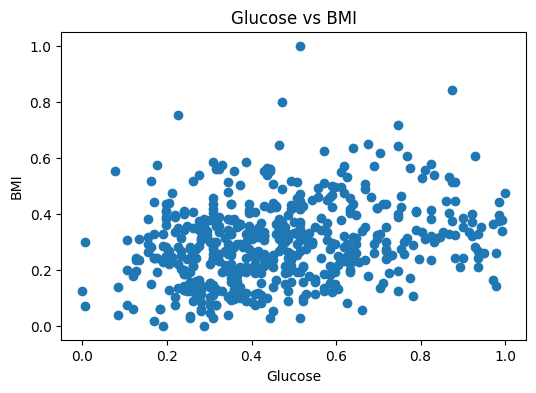

In [26]:
#After Standard Scaling
plt.figure(figsize=(6, 4))
plt.scatter(X_train_scaled["Glucose"], X_train_scaled["BMI"])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

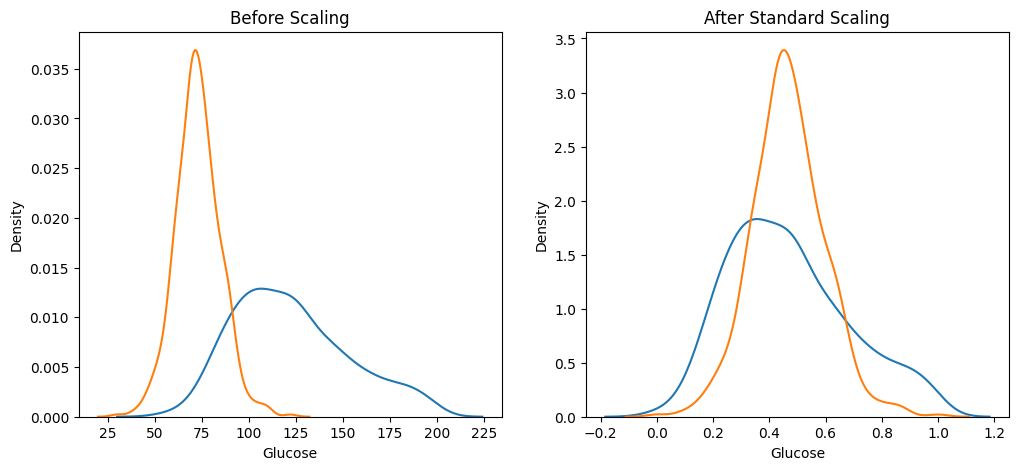

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Glucose'], ax=ax1)
sns.kdeplot(X_train['BloodPressure'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Glucose'], ax=ax2)
sns.kdeplot(X_train_scaled['BloodPressure'], ax=ax2)
plt.show()